
# Workplace Flexibility and Employee Productivity Among Gen Z Employees  
## Python Evidence Matrix Analysis



In [40]:

# 1. Import libraries and set paths

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Project folders
PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# File paths
SCREENING_PATH = DATA_DIR / "/content/screening_log.csv"
RAW_MATRIX_PATH = DATA_DIR / "/content/evidence_matrix_raw.csv"
CLEAN_MATRIX_PATH = DATA_DIR / "/content/evidence_matrix_clean.csv"

print("Working directory:", PROJECT_DIR.resolve())
print("Data directory exists:", DATA_DIR.exists())


Working directory: /content
Data directory exists: False


In [41]:

# 2. Load the datasets

screening_df = pd.read_csv(SCREENING_PATH)
raw_df = pd.read_csv(RAW_MATRIX_PATH)
df = pd.read_csv(CLEAN_MATRIX_PATH)

print("Screening log shape:", screening_df.shape)
print("Raw evidence matrix shape:", raw_df.shape)
print("Clean evidence matrix shape:", df.shape)

df.head()


Screening log shape: (25, 18)
Raw evidence matrix shape: (39, 32)
Clean evidence matrix shape: (34, 39)


,row_id,study_id,author_year,title,year,country,sector,population_group,sample_size,gen_z_relevance,study_design,source_type,flexibility_type,flexibility_measure,outcome_category,outcome_measure,measure_type,effect_direction,effect_size_value,effect_size_type,p_value,significant,moderators_or_mechanisms,main_finding,quality_score_preliminary,extraction_confidence,analysis_ready,doi,article_url,pdf_url,harvard_reference,notes_for_validation,sample_size_numeric,effect_size_numeric,p_value_numeric,quality_score_numeric,quality_band,direct_productivity_flag,primary_analysis_flag
0,S001_E01,S001,Febriana and Mujib (2024),Increasing productivity of Gen Z employees: Th...,2024,Indonesia,Mixed/unspecified,Generation Z employees,259.0,Direct,Quantitative survey; structural modelling,Peer-reviewed journal article,Flexible work arrangements,Time and place flexibility,Self-reported productivity,Employee productivity,Subjective,Positive,NaN,NaN,NaN,Yes,Participative style; emotional engagement,Flexible work arrangements were reported to in...,8,High,Yes,10.4102/sajhrm.v22i0.2489,https://sajhrm.co.za/index.php/SAJHRM/article/...,https://sajhrm.co.za/index.php/sajhrm/article/...,"Febriana, A. and Mujib, M. (2024) 'Increasing ...","Directly examines Gen Z employees, flexible wo...",259.0,NaN,NaN,8.0,High,Yes,Yes
1,S001_E02,S001,Febriana and Mujib (2024),Increasing productivity of Gen Z employees: Th...,2024,Indonesia,Mixed/unspecified,Generation Z employees,259.0,Direct,Quantitative survey; structural modelling,Peer-reviewed journal article,Flexible work arrangements,Time and place flexibility,Engagement,Emotional engagement,Subjective,Neutral,NaN,NaN,0.058,No,Emotional engagement,Flexible work arrangements did not show a stat...,8,High,Yes,10.4102/sajhrm.v22i0.2489,https://sajhrm.co.za/index.php/SAJHRM/article/...,https://sajhrm.co.za/index.php/sajhrm/article/...,"Febriana, A. and Mujib, M. (2024) 'Increasing ...","Directly examines Gen Z employees, flexible wo...",259.0,NaN,0.058,8.0,High,No,Yes
2,S002_E01,S002,Wilda et al. (2026),The relationship between flexible work arrange...,2026,Malaysia,Telecommunications,Generation Z employees,86.0,Direct,Quantitative survey; correlation/regression,Journal article,Flexible work arrangements,Flexible work options,Performance,Work performance,Subjective,Positive,NaN,Correlation/regression result,NaN,Yes,Autonomy; job resources,Reported moderate positive relationship betwee...,6,Moderate,Yes,10.47772/IJRISS.2026.10200214,https://rsisinternational.org/journals/ijriss/...,https://rsisinternational.org/journals/ijriss/...,"Wilda, A., Hassan, M.A., Abd Hamid, M.A., Zool...",Direct Gen Z flexible work-performance study; ...,86.0,NaN,NaN,6.0,Moderate,Yes,Yes
3,S003_E01,S003,Kgarimetsa and Naidoo (2024),Effect of employee recognition and flexible wo...,2024,South Africa,Mining,Generation Z employees,NaN,Direct,Quantitative survey,Peer-reviewed journal article,Flexible work arrangements,Flexible working arrangement,Retention,Gen Z retention,Subjective,Positive,NaN,Regression/correlation result,NaN,Yes,Recognition; retention strategy,Flexible working arrangement was positively re...,7,Moderate,Yes,10.4102/sajhrm.v22i0.2770,https://sajhrm.co.za/index.php/sajhrm/article/...,https://sajhrm.co.za/index.php/sajhrm/article/...,"Kgarimetsa, T.S. and Naidoo, C. (2024) 'Effect...",Direct Gen Z retention outcome; retention is a...,NaN,NaN,NaN,7.0,Moderate,No,Yes
4,S004_E01,S004,Saputro and Winarsih (2026),The influence of the hybrid working system and...,2026,Indonesia,Private company,Generation Z employees,NaN,Direct,Quantitative survey; regression,Journal article,Hybrid work,Hybrid working system,Self-reported productivity,Work productivity,Subjective,Positive,2.358,t-statistic,0.025,Yes,Work discipline; digital technology; output-ba...,Hybrid working system showed a positive and si...,6,High,Yes,10.58812/esmb.v4i03.1018,https://esj.eastasouth-institute.com/index.php...,https://esj.eastasouth-institute.com/index.php...


## 3. Inspect the evidence matrix



In [42]:

# Dataset structure

print("Columns in the clean evidence matrix:")
for col in df.columns:
    print("-", col)

df.info()


Columns in the clean evidence matrix:
- row_id
- study_id
- author_year
- title
- year
- country
- sector
- population_group
- sample_size
- gen_z_relevance
- study_design
- source_type
- flexibility_type
- flexibility_measure
- outcome_category
- outcome_measure
- measure_type
- effect_direction
- effect_size_value
- effect_size_type
- p_value
- significant
- moderators_or_mechanisms
- main_finding
- quality_score_preliminary
- extraction_confidence
- analysis_ready
- doi
- article_url
- pdf_url
- harvard_reference
- notes_for_validation
- sample_size_numeric
- effect_size_numeric
- p_value_numeric
- quality_score_numeric
- quality_band
- direct_productivity_flag
- primary_analysis_flag
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   row_id                     34 non-null     object 
 1   study_id                   

In [43]:

# Missing values summary

missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_values"]
missing_summary["missing_percentage"] = (
    missing_summary["missing_values"] / len(df) * 100
).round(1)

missing_summary.to_csv(TABLE_DIR / "missing_values_summary.csv", index=False)
missing_summary.head(20)


,column,missing_values,missing_percentage
0,p_value,30,88.2
1,p_value_numeric,30,88.2
2,sample_size_numeric,23,67.6
3,sample_size,23,67.6
4,effect_size_value,19,55.9
5,effect_size_numeric,19,55.9
6,significant,15,44.1
7,effect_size_type,2,5.9
8,sector,0,0.0
9,year,0,0.0



## 4. Validate coding categories



In [44]:

# Expected coding categories

expected_categories = {
    "effect_direction": {"Positive", "Negative", "Neutral", "Mixed"},
    "gen_z_relevance": {"Direct", "Partial", "Indirect"},
    "measure_type": {"Objective", "Subjective", "Mixed", "Not reported"},
    "analysis_ready": {"Yes", "No"},
    "quality_band": {"Low", "Moderate", "High"},
    "direct_productivity_flag": {"Yes", "No"},
    "primary_analysis_flag": {"Yes", "No"}
}

validation_results = []

for column, allowed_values in expected_categories.items():
    if column in df.columns:
        observed_values = set(df[column].dropna().astype(str).unique())
        invalid_values = observed_values - allowed_values
        validation_results.append({
            "column": column,
            "allowed_values": ", ".join(sorted(allowed_values)),
            "observed_values": ", ".join(sorted(observed_values)),
            "invalid_values": ", ".join(sorted(invalid_values)) if invalid_values else "None"
        })

validation_df = pd.DataFrame(validation_results)
validation_df.to_csv(TABLE_DIR / "category_validation_results.csv", index=False)
validation_df


,column,allowed_values,observed_values,invalid_values
0,effect_direction,"Mixed, Negative, Neutral, Positive","Mixed, Negative, Neutral, Positive",None
1,gen_z_relevance,"Direct, Indirect, Partial","Direct, Indirect",None
2,measure_type,"Mixed, Not reported, Objective, Subjective","Modelled/objective, Objective, Objective digit...","Modelled/objective, Objective digital trace, O..."
3,analysis_ready,"No, Yes",Yes,None
4,quality_band,"High, Low, Moderate","High, Low, Moderate",None
5,direct_productivity_flag,"No, Yes","No, Yes",None
6,primary_analysis_flag,"No, Yes","No, Yes",None


In [45]:

# Check duplicate extracted relationships

duplicate_subset = [
    "study_id",
    "flexibility_type",
    "outcome_category",
    "outcome_measure",
    "effect_direction"
]

existing_subset = [col for col in duplicate_subset if col in df.columns]

duplicates = df[df.duplicated(subset=existing_subset, keep=False)].sort_values(existing_subset)

print("Number of potential duplicate rows:", len(duplicates))
duplicates.head(20)


Number of potential duplicate rows: 0


,row_id,study_id,author_year,title,year,country,sector,population_group,sample_size,gen_z_relevance,study_design,source_type,flexibility_type,flexibility_measure,outcome_category,outcome_measure,measure_type,effect_direction,effect_size_value,effect_size_type,p_value,significant,moderators_or_mechanisms,main_finding,quality_score_preliminary,extraction_confidence,analysis_ready,doi,article_url,pdf_url,harvard_reference,notes_for_validation,sample_size_numeric,effect_size_numeric,p_value_numeric,quality_score_numeric,quality_band,direct_productivity_flag,primary_analysis_flag



## 5. Screening summary

This produces simple screening outputs to support the methodology chapter and a PRISMA-style flow description.


In [46]:

# Screening decision summary

screening_summary = (
    screening_df["final_decision"]
    .value_counts(dropna=False)
    .reset_index()
)

screening_summary.columns = ["final_decision", "count"]
screening_summary.to_csv(TABLE_DIR / "screening_decision_summary.csv", index=False)
screening_summary


,final_decision,count
0,Include - direct Gen Z quantitative evidence,2
1,Include - high-quality indirect productivity e...,2
2,Include as context evidence,2
3,Include - direct Gen Z performance/engagement ...,1
4,Include - direct Gen Z productivity evidence,1
5,Include - direct Gen Z organisational outcome ...,1
6,Include candidate - quality check needed,1
7,Include candidate - needs full-text extraction,1
8,Include - high-quality indirect evidence,1
9,Include - direct Gen Z contextual evidence,1


In [47]:

# Screening decisions by Gen Z relevance

screening_by_genz = pd.crosstab(
    screening_df["gen_z_relevance"],
    screening_df["final_decision"]
)

screening_by_genz.to_csv(TABLE_DIR / "screening_by_gen_z_relevance.csv")
screening_by_genz


final_decision,Include - direct Gen Z contextual evidence,Include - direct Gen Z organisational outcome evidence,Include - direct Gen Z performance/engagement evidence,Include - direct Gen Z productivity evidence,Include - direct Gen Z quantitative evidence,Include - high-quality indirect evidence,Include - high-quality indirect productivity evidence,Include - indirect benefits/costs evidence,Include - indirect collaboration evidence,Include - indirect innovation evidence,Include - indirect negative productivity evidence,Include - indirect pandemic performance evidence,Include - indirect perceived productivity evidence,Include - indirect productivity evidence,Include - indirect productivity/context evidence,Include - indirect productivity/well-being evidence,Include - indirect remote work productivity evidence,Include as context evidence,Include as preference/context evidence,Include as theory/framework only,Include candidate - needs full-text extraction,Include candidate - quality check needed
gen_z_relevance,,,,,,,,,,,,,,,,,,,,,,
Direct,1,1,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
Indirect,0,0,0,0,0,1,2,1,1,1,1,1,1,1,1,1,1,2,1,1,0,0



## 6. Dataset summary



In [48]:

# Basic dataset summary

unique_studies = df["study_id"].nunique()
evidence_rows = len(df)
year_min = int(df["year"].min())
year_max = int(df["year"].max())
countries = df["country"].nunique()
sectors = df["sector"].nunique()

# Avoid double-counting sample sizes by using one row per study.
study_level = df.drop_duplicates("study_id").copy()
reported_total_sample = study_level["sample_size_numeric"].sum(skipna=True)

dataset_summary = pd.DataFrame({
    "metric": [
        "Unique included studies",
        "Extracted evidence rows",
        "Publication year range",
        "Countries represented",
        "Sectors represented",
        "Sum of reported study sample sizes"
    ],
    "value": [
        unique_studies,
        evidence_rows,
        f"{year_min}–{year_max}",
        countries,
        sectors,
        reported_total_sample
    ]
})

dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)
dataset_summary


,metric,value
0,Unique included studies,22
1,Extracted evidence rows,34
2,Publication year range,2020–2026
3,Countries represented,15
4,Sectors represented,13
5,Sum of reported study sample sizes,63455.0


In [49]:

# Number of unique studies by year

studies_by_year = (
    study_level
    .groupby("year")
    .size()
    .reset_index(name="number_of_studies")
    .sort_values("year")
)

studies_by_year.to_csv(TABLE_DIR / "studies_by_year.csv", index=False)
studies_by_year


,year,number_of_studies
0,2020,1
1,2021,6
2,2022,4
3,2023,4
4,2024,5
5,2026,2


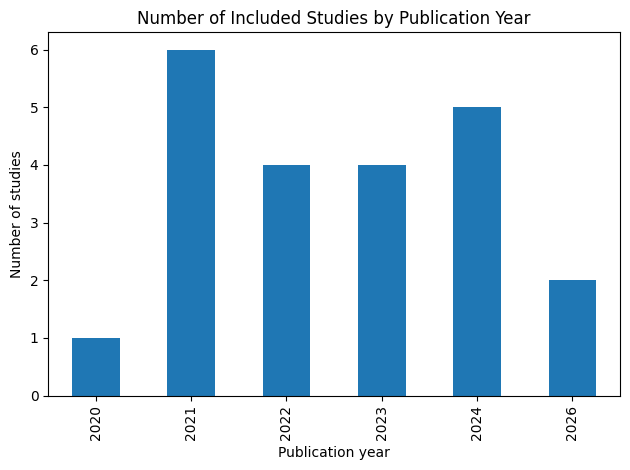

In [50]:

# Chart: studies by publication year

ax = studies_by_year.plot(
    x="year",
    y="number_of_studies",
    kind="bar",
    legend=False
)

ax.set_title("Number of Included Studies by Publication Year")
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of studies")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "studies_by_year.png", dpi=300)
plt.show()



## 7. Flexibility type analysis



In [51]:

# Frequency of flexibility types

flexibility_counts = (
    df["flexibility_type"]
    .value_counts(dropna=False)
    .reset_index()
)

flexibility_counts.columns = ["flexibility_type", "count"]
flexibility_counts["percentage"] = (
    flexibility_counts["count"] / flexibility_counts["count"].sum() * 100
).round(1)

flexibility_counts.to_csv(TABLE_DIR / "flexibility_type_counts.csv", index=False)
flexibility_counts


,flexibility_type,count,percentage
0,Remote work,21,61.8
1,Hybrid work,7,20.6
2,Flexible work arrangements,4,11.8
3,Work-from-anywhere,2,5.9


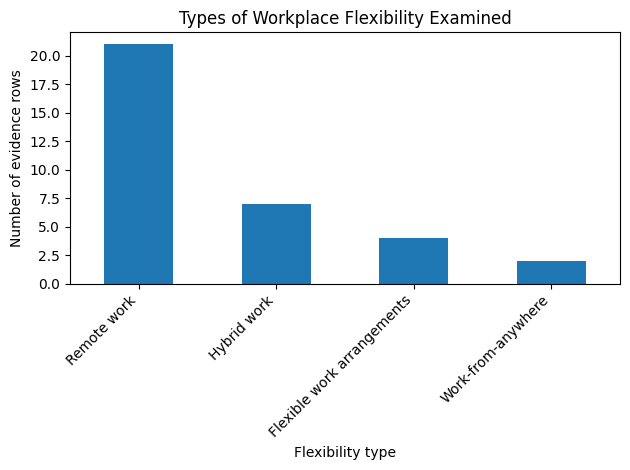

In [52]:

# Chart: flexibility types

ax = flexibility_counts.plot(
    x="flexibility_type",
    y="count",
    kind="bar",
    legend=False
)

ax.set_title("Types of Workplace Flexibility Examined")
ax.set_xlabel("Flexibility type")
ax.set_ylabel("Number of evidence rows")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "flexibility_types.png", dpi=300)
plt.show()



## 8. Outcome category analysis



In [53]:

# Frequency of outcome categories

outcome_counts = (
    df["outcome_category"]
    .value_counts(dropna=False)
    .reset_index()
)

outcome_counts.columns = ["outcome_category", "count"]
outcome_counts["percentage"] = (
    outcome_counts["count"] / outcome_counts["count"].sum() * 100
).round(1)

outcome_counts.to_csv(TABLE_DIR / "outcome_category_counts.csv", index=False)
outcome_counts


,outcome_category,count,percentage
0,Self-reported productivity,7,20.6
1,Objective productivity,6,17.6
2,Performance,4,11.8
3,Wellbeing,4,11.8
4,Engagement,2,5.9
5,Retention,2,5.9
6,Context,2,5.9
7,Preference,2,5.9
8,Satisfaction,1,2.9
9,Collaboration,1,2.9


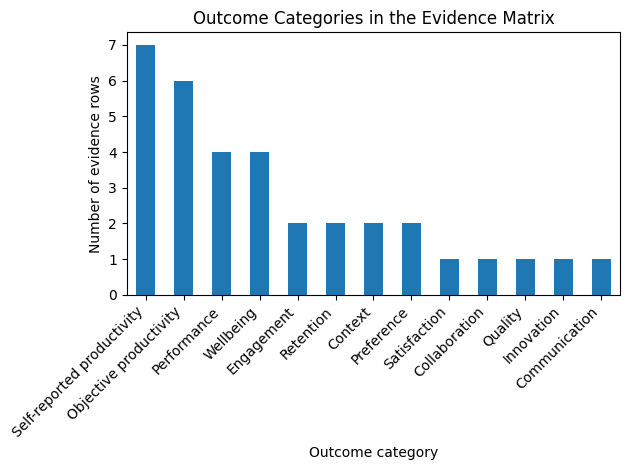

In [54]:

# Chart: outcome categories

ax = outcome_counts.plot(
    x="outcome_category",
    y="count",
    kind="bar",
    legend=False
)

ax.set_title("Outcome Categories in the Evidence Matrix")
ax.set_xlabel("Outcome category")
ax.set_ylabel("Number of evidence rows")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "outcome_categories.png", dpi=300)
plt.show()



## 9. Direction of reported relationships



In [55]:

# Direction of reported relationships

direction_order = ["Positive", "Neutral", "Negative", "Mixed"]

effect_direction_counts = (
    df["effect_direction"]
    .value_counts()
    .reindex(direction_order)
    .dropna()
    .reset_index()
)

effect_direction_counts.columns = ["effect_direction", "count"]
effect_direction_counts["percentage"] = (
    effect_direction_counts["count"] / effect_direction_counts["count"].sum() * 100
).round(1)

effect_direction_counts.to_csv(TABLE_DIR / "effect_direction_counts.csv", index=False)
effect_direction_counts


,effect_direction,count,percentage
0,Positive,18,52.9
1,Neutral,3,8.8
2,Negative,7,20.6
3,Mixed,6,17.6


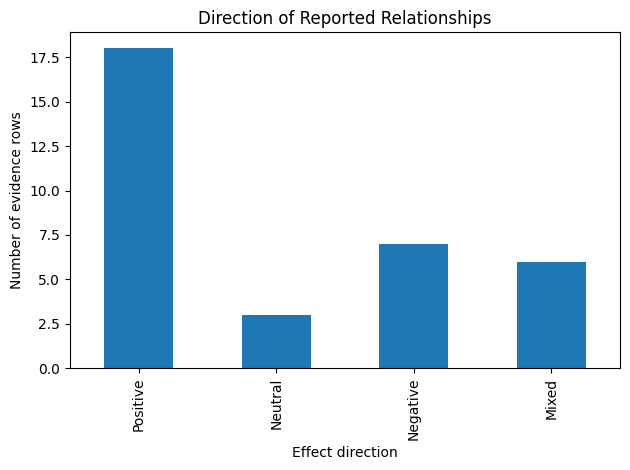

In [56]:

# Chart: effect direction

ax = effect_direction_counts.plot(
    x="effect_direction",
    y="count",
    kind="bar",
    legend=False
)

ax.set_title("Direction of Reported Relationships")
ax.set_xlabel("Effect direction")
ax.set_ylabel("Number of evidence rows")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "effect_direction_counts.png", dpi=300)
plt.show()



## 10. Flexibility type by effect direction



In [57]:

# Cross-tabulation: flexibility type by effect direction

flexibility_direction_counts = pd.crosstab(
    df["flexibility_type"],
    df["effect_direction"]
)

# Reorder columns where possible
flexibility_direction_counts = flexibility_direction_counts.reindex(
    columns=[col for col in direction_order if col in flexibility_direction_counts.columns],
    fill_value=0
)

flexibility_direction_percent = pd.crosstab(
    df["flexibility_type"],
    df["effect_direction"],
    normalize="index"
).mul(100).round(1)

flexibility_direction_percent = flexibility_direction_percent.reindex(
    columns=[col for col in direction_order if col in flexibility_direction_percent.columns],
    fill_value=0
)

flexibility_direction_counts.to_csv(TABLE_DIR / "flexibility_by_effect_direction_counts.csv")
flexibility_direction_percent.to_csv(TABLE_DIR / "flexibility_by_effect_direction_percent.csv")

flexibility_direction_counts


effect_direction,Positive,Neutral,Negative,Mixed
flexibility_type,,,,
Flexible work arrangements,3,1,0,0
Hybrid work,5,1,0,1
Remote work,9,0,7,5
Work-from-anywhere,1,1,0,0


In [58]:

flexibility_direction_percent


effect_direction,Positive,Neutral,Negative,Mixed
flexibility_type,,,,
Flexible work arrangements,75.0,25.0,0.0,0.0
Hybrid work,71.4,14.3,0.0,14.3
Remote work,42.9,0.0,33.3,23.8
Work-from-anywhere,50.0,50.0,0.0,0.0


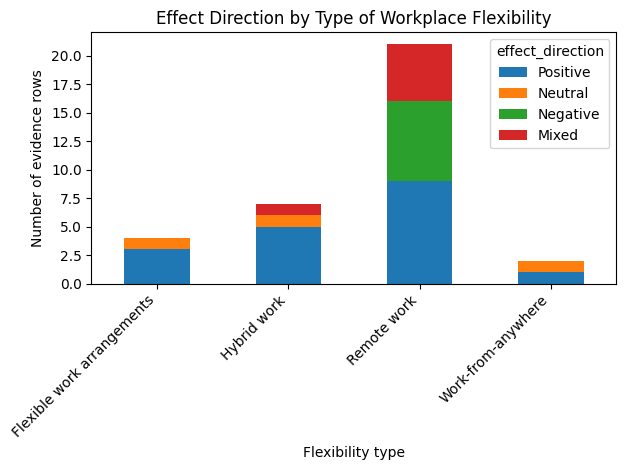

In [59]:

# Stacked bar chart: flexibility type by effect direction

ax = flexibility_direction_counts.plot(kind="bar", stacked=True)

ax.set_title("Effect Direction by Type of Workplace Flexibility")
ax.set_xlabel("Flexibility type")
ax.set_ylabel("Number of evidence rows")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "flexibility_by_effect_direction.png", dpi=300)
plt.show()



## 11. Gen Z relevance analysis



In [60]:

# Cross-tabulation: Gen Z relevance by effect direction

genz_direction_counts = pd.crosstab(
    df["gen_z_relevance"],
    df["effect_direction"]
)

genz_direction_counts = genz_direction_counts.reindex(
    columns=[col for col in direction_order if col in genz_direction_counts.columns],
    fill_value=0
)

genz_direction_percent = pd.crosstab(
    df["gen_z_relevance"],
    df["effect_direction"],
    normalize="index"
).mul(100).round(1)

genz_direction_percent = genz_direction_percent.reindex(
    columns=[col for col in direction_order if col in genz_direction_percent.columns],
    fill_value=0
)

genz_direction_counts.to_csv(TABLE_DIR / "gen_z_relevance_by_effect_direction_counts.csv")
genz_direction_percent.to_csv(TABLE_DIR / "gen_z_relevance_by_effect_direction_percent.csv")

genz_direction_counts


effect_direction,Positive,Neutral,Negative,Mixed
gen_z_relevance,,,,
Direct,8,1,1,0
Indirect,10,2,6,6


In [61]:

genz_direction_percent


effect_direction,Positive,Neutral,Negative,Mixed
gen_z_relevance,,,,
Direct,80.0,10.0,10.0,0.0
Indirect,41.7,8.3,25.0,25.0


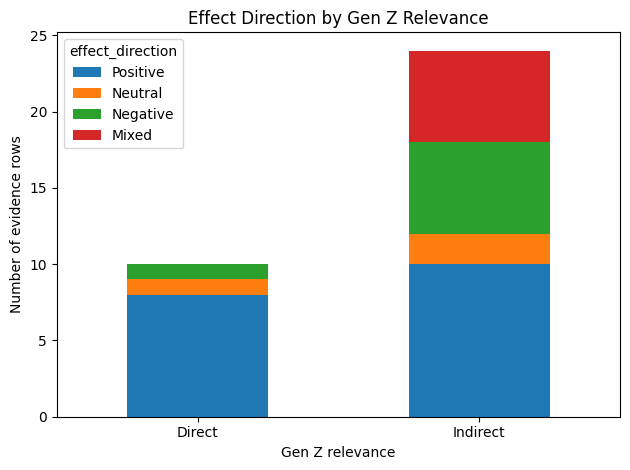

In [62]:

# Chart: Gen Z relevance by effect direction

ax = genz_direction_counts.plot(kind="bar", stacked=True)

ax.set_title("Effect Direction by Gen Z Relevance")
ax.set_xlabel("Gen Z relevance")
ax.set_ylabel("Number of evidence rows")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "gen_z_relevance_by_effect_direction.png", dpi=300)
plt.show()



## 12. Direct productivity analysis



In [63]:

# Direct productivity subset

productivity_df = df[df["direct_productivity_flag"] == "Yes"].copy()

print("Direct productivity evidence rows:", len(productivity_df))
print("Unique studies in direct productivity subset:", productivity_df["study_id"].nunique())

productivity_direction_counts = (
    productivity_df["effect_direction"]
    .value_counts()
    .reindex(direction_order)
    .dropna()
    .reset_index()
)

productivity_direction_counts.columns = ["effect_direction", "count"]
productivity_direction_counts["percentage"] = (
    productivity_direction_counts["count"] / productivity_direction_counts["count"].sum() * 100
).round(1)

productivity_direction_counts.to_csv(TABLE_DIR / "direct_productivity_effect_direction_counts.csv", index=False)
productivity_direction_counts


Direct productivity evidence rows: 17
Unique studies in direct productivity subset: 14


,effect_direction,count,percentage
0,Positive,8,47.1
1,Neutral,1,5.9
2,Negative,5,29.4
3,Mixed,3,17.6


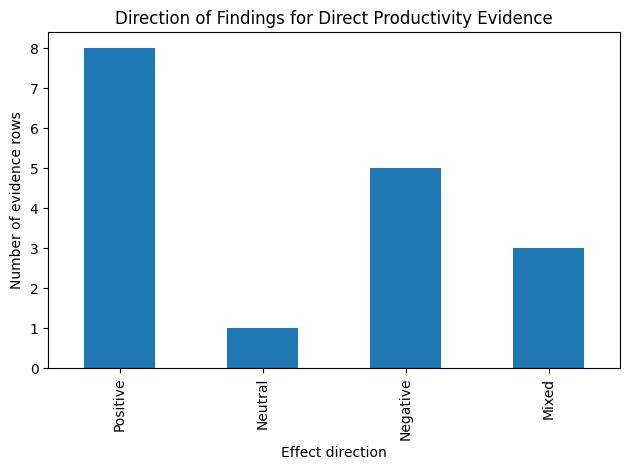

In [64]:

# Chart: direct productivity evidence only

ax = productivity_direction_counts.plot(
    x="effect_direction",
    y="count",
    kind="bar",
    legend=False
)

ax.set_title("Direction of Findings for Direct Productivity Evidence")
ax.set_xlabel("Effect direction")
ax.set_ylabel("Number of evidence rows")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "direct_productivity_effect_direction.png", dpi=300)
plt.show()



## 13. Objective versus subjective measurement



In [65]:

# Cross-tabulation: measurement type by effect direction

measure_direction_counts = pd.crosstab(
    df["measure_type"],
    df["effect_direction"]
)

measure_direction_counts = measure_direction_counts.reindex(
    columns=[col for col in direction_order if col in measure_direction_counts.columns],
    fill_value=0
)

measure_direction_percent = pd.crosstab(
    df["measure_type"],
    df["effect_direction"],
    normalize="index"
).mul(100).round(1)

measure_direction_percent = measure_direction_percent.reindex(
    columns=[col for col in direction_order if col in measure_direction_percent.columns],
    fill_value=0
)

measure_direction_counts.to_csv(TABLE_DIR / "measure_type_by_effect_direction_counts.csv")
measure_direction_percent.to_csv(TABLE_DIR / "measure_type_by_effect_direction_percent.csv")

measure_direction_counts


effect_direction,Positive,Neutral,Negative,Mixed
measure_type,,,,
Modelled/objective,2,0,0,0
Objective,2,1,2,1
Objective digital trace,0,0,1,1
Objective/descriptive,2,0,0,0
Objective/manager-rated,0,1,0,0
Objective/subjective mixed,0,0,0,1
Subjective,12,1,4,2
Subjective/quantitative,0,0,0,1


In [66]:

measure_direction_percent


effect_direction,Positive,Neutral,Negative,Mixed
measure_type,,,,
Modelled/objective,100.0,0.0,0.0,0.0
Objective,33.3,16.7,33.3,16.7
Objective digital trace,0.0,0.0,50.0,50.0
Objective/descriptive,100.0,0.0,0.0,0.0
Objective/manager-rated,0.0,100.0,0.0,0.0
Objective/subjective mixed,0.0,0.0,0.0,100.0
Subjective,63.2,5.3,21.1,10.5
Subjective/quantitative,0.0,0.0,0.0,100.0



## 14. Quality-score analysis



In [67]:

# Quality band summary

quality_counts = (
    df["quality_band"]
    .value_counts()
    .reindex(["High", "Moderate", "Low"])
    .dropna()
    .reset_index()
)

quality_counts.columns = ["quality_band", "count"]
quality_counts["percentage"] = (
    quality_counts["count"] / quality_counts["count"].sum() * 100
).round(1)

quality_counts.to_csv(TABLE_DIR / "quality_band_counts.csv", index=False)
quality_counts


,quality_band,count,percentage
0,High,18,52.9
1,Moderate,13,38.2
2,Low,3,8.8


In [68]:

# Cross-tabulation: quality band by effect direction

quality_direction_counts = pd.crosstab(
    df["quality_band"],
    df["effect_direction"]
)

quality_direction_counts = quality_direction_counts.reindex(
    index=["High", "Moderate", "Low"],
    columns=[col for col in direction_order if col in quality_direction_counts.columns],
    fill_value=0
).dropna(how="all")

quality_direction_percent = pd.crosstab(
    df["quality_band"],
    df["effect_direction"],
    normalize="index"
).mul(100).round(1)

quality_direction_percent = quality_direction_percent.reindex(
    index=["High", "Moderate", "Low"],
    columns=[col for col in direction_order if col in quality_direction_percent.columns],
    fill_value=0
).dropna(how="all")

quality_direction_counts.to_csv(TABLE_DIR / "quality_band_by_effect_direction_counts.csv")
quality_direction_percent.to_csv(TABLE_DIR / "quality_band_by_effect_direction_percent.csv")

quality_direction_counts


effect_direction,Positive,Neutral,Negative,Mixed
quality_band,,,,
High,6,3,4,5
Moderate,10,0,2,1
Low,2,0,1,0


In [69]:

quality_direction_percent


effect_direction,Positive,Neutral,Negative,Mixed
quality_band,,,,
High,33.3,16.7,22.2,27.8
Moderate,76.9,0.0,15.4,7.7
Low,66.7,0.0,33.3,0.0


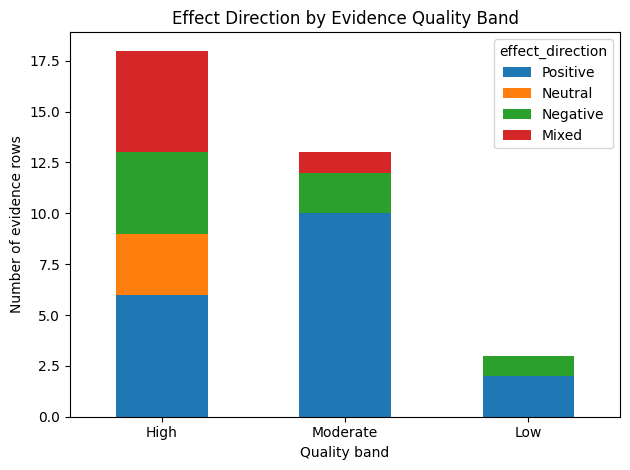

In [70]:

# Chart: quality band by effect direction

ax = quality_direction_counts.plot(kind="bar", stacked=True)

ax.set_title("Effect Direction by Evidence Quality Band")
ax.set_xlabel("Quality band")
ax.set_ylabel("Number of evidence rows")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "quality_band_by_effect_direction.png", dpi=300)
plt.show()



## 15. Country and sector analysis



In [71]:

# Countries represented

country_counts = (
    df.drop_duplicates("study_id")["country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "number_of_studies"]
country_counts.to_csv(TABLE_DIR / "country_counts.csv", index=False)
country_counts


,country,number_of_studies
0,United States,4
1,Indonesia,3
2,China,2
3,Italy,2
4,South Africa,1
5,Poland,1
6,Malaysia,1
7,India,1
8,United States/global company,1
9,United Kingdom,1


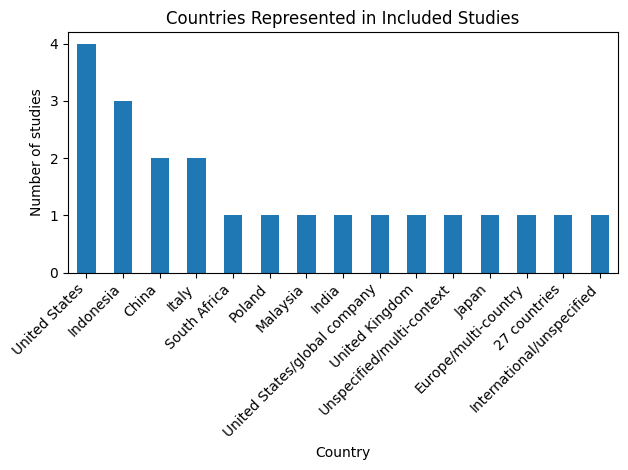

In [72]:

# Chart: countries represented

ax = country_counts.plot(
    x="country",
    y="number_of_studies",
    kind="bar",
    legend=False
)

ax.set_title("Countries Represented in Included Studies")
ax.set_xlabel("Country")
ax.set_ylabel("Number of studies")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "countries_represented.png", dpi=300)
plt.show()


In [73]:

# Sectors represented

sector_counts = (
    df.drop_duplicates("study_id")["sector"]
    .value_counts()
    .reset_index()
)

sector_counts.columns = ["sector", "number_of_studies"]
sector_counts.to_csv(TABLE_DIR / "sector_counts.csv", index=False)
sector_counts


,sector,number_of_studies
0,Mixed,8
1,Software development,2
2,Mixed/unspecified,2
3,Telecommunications,1
4,Mining,1
5,Young employees/mixed,1
6,Private company,1
7,Public sector/patent examination,1
8,Technology/travel services,1
9,Data entry,1



## 16. Heat-map style table: flexibility type by outcome category



In [74]:

# Heat-map style cross-tabulation table

flexibility_outcome_counts = pd.crosstab(
    df["flexibility_type"],
    df["outcome_category"]
)

flexibility_outcome_counts.to_csv(TABLE_DIR / "flexibility_by_outcome_category_counts.csv")
flexibility_outcome_counts


outcome_category,Collaboration,Communication,Context,Engagement,Innovation,Objective productivity,Performance,Preference,Quality,Retention,Satisfaction,Self-reported productivity,Wellbeing
flexibility_type,,,,,,,,,,,,,
Flexible work arrangements,0,0,0,1,0,0,1,0,0,1,0,1,0
Hybrid work,0,0,0,1,1,0,2,0,0,1,1,1,0
Remote work,1,1,2,0,0,5,1,2,0,0,0,5,4
Work-from-anywhere,0,0,0,0,0,1,0,0,1,0,0,0,0


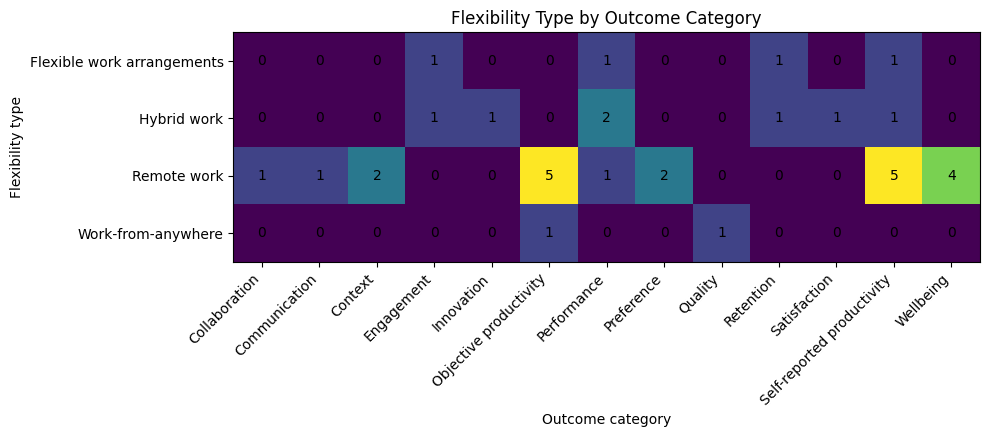

In [75]:

# Visual heat map using matplotlib

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(flexibility_outcome_counts.values)

ax.set_xticks(range(len(flexibility_outcome_counts.columns)))
ax.set_yticks(range(len(flexibility_outcome_counts.index)))
ax.set_xticklabels(flexibility_outcome_counts.columns, rotation=45, ha="right")
ax.set_yticklabels(flexibility_outcome_counts.index)

for i in range(len(flexibility_outcome_counts.index)):
    for j in range(len(flexibility_outcome_counts.columns)):
        ax.text(j, i, flexibility_outcome_counts.values[i, j], ha="center", va="center")

ax.set_title("Flexibility Type by Outcome Category")
ax.set_xlabel("Outcome category")
ax.set_ylabel("Flexibility type")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "flexibility_by_outcome_heatmap.png", dpi=300)
plt.show()



## 17. Final evidence summary table



In [76]:

# Final evidence summary table

summary_columns = [
    "row_id",
    "study_id",
    "author_year",
    "year",
    "country",
    "sector",
    "gen_z_relevance",
    "flexibility_type",
    "outcome_category",
    "outcome_measure",
    "measure_type",
    "effect_direction",
    "effect_size_value",
    "effect_size_type",
    "p_value",
    "significant",
    "quality_score_numeric",
    "quality_band",
    "direct_productivity_flag",
    "main_finding",
    "harvard_reference",
    "pdf_url"
]

existing_summary_columns = [col for col in summary_columns if col in df.columns]

final_evidence_summary = df[existing_summary_columns].copy()
final_evidence_summary.to_csv(TABLE_DIR / "final_evidence_matrix_summary.csv", index=False)

final_evidence_summary.head()


,row_id,study_id,author_year,year,country,sector,gen_z_relevance,flexibility_type,outcome_category,outcome_measure,measure_type,effect_direction,effect_size_value,effect_size_type,p_value,significant,quality_score_numeric,quality_band,direct_productivity_flag,main_finding,harvard_reference,pdf_url
0,S001_E01,S001,Febriana and Mujib (2024),2024,Indonesia,Mixed/unspecified,Direct,Flexible work arrangements,Self-reported productivity,Employee productivity,Subjective,Positive,NaN,NaN,NaN,Yes,8.0,High,Yes,Flexible work arrangements were reported to in...,"Febriana, A. and Mujib, M. (2024) 'Increasing ...",https://sajhrm.co.za/index.php/sajhrm/article/...
1,S001_E02,S001,Febriana and Mujib (2024),2024,Indonesia,Mixed/unspecified,Direct,Flexible work arrangements,Engagement,Emotional engagement,Subjective,Neutral,NaN,NaN,0.058,No,8.0,High,No,Flexible work arrangements did not show a stat...,"Febriana, A. and Mujib, M. (2024) 'Increasing ...",https://sajhrm.co.za/index.php/sajhrm/article/...
2,S002_E01,S002,Wilda et al. (2026),2026,Malaysia,Telecommunications,Direct,Flexible work arrangements,Performance,Work performance,Subjective,Positive,NaN,Correlation/regression result,NaN,Yes,6.0,Moderate,Yes,Reported moderate positive relationship betwee...,"Wilda, A., Hassan, M.A., Abd Hamid, M.A., Zool...",https://rsisinternational.org/journals/ijriss/...
3,S003_E01,S003,Kgarimetsa and Naidoo (2024),2024,South Africa,Mining,Direct,Flexible work arrangements,Retention,Gen Z retention,Subjective,Positive,NaN,Regression/correlation result,NaN,Yes,7.0,Moderate,No,Flexible working arrangement was positively re...,"Kgarimetsa, T.S. and Naidoo, C. (2024) 'Effect...",https://sajhrm.co.za/index.php/sajhrm/article/...
4,S004_E01,S004,Saputro and Winarsih (2026),2026,Indonesia,Private company,Direct,Hybrid work,Self-reported productivity,Work productivity,Subjective,Positive,2.358,t-statistic,0.025,Yes,6.0,Moderate,Yes,Hybrid working system showed a positive and si...,"Saputro, Y. and Winarsih, T. (2026) 'The influ...",https://esj.eastasouth-institute.com/index.php...



## 18. Interpretation helper



In [77]:

# List exported files

print("Exported tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print("-", path)

print("\nExported figures:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path)


Exported tables:
- outputs/tables/category_validation_results.csv
- outputs/tables/country_counts.csv
- outputs/tables/dataset_summary.csv
- outputs/tables/direct_productivity_effect_direction_counts.csv
- outputs/tables/effect_direction_counts.csv
- outputs/tables/final_evidence_matrix_summary.csv
- outputs/tables/flexibility_by_effect_direction_counts.csv
- outputs/tables/flexibility_by_effect_direction_percent.csv
- outputs/tables/flexibility_by_outcome_category_counts.csv
- outputs/tables/flexibility_type_counts.csv
- outputs/tables/gen_z_relevance_by_effect_direction_counts.csv
- outputs/tables/gen_z_relevance_by_effect_direction_percent.csv
- outputs/tables/measure_type_by_effect_direction_counts.csv
- outputs/tables/measure_type_by_effect_direction_percent.csv
- outputs/tables/missing_values_summary.csv
- outputs/tables/outcome_category_counts.csv
- outputs/tables/quality_band_by_effect_direction_counts.csv
- outputs/tables/quality_band_by_effect_direction_percent.csv
- outputs/